In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv("Social_Network_Ads.csv")
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [8]:
data.isna().sum()

User ID            0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

array([[<Axes: title={'center': 'User ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Purchased'}>]], dtype=object)

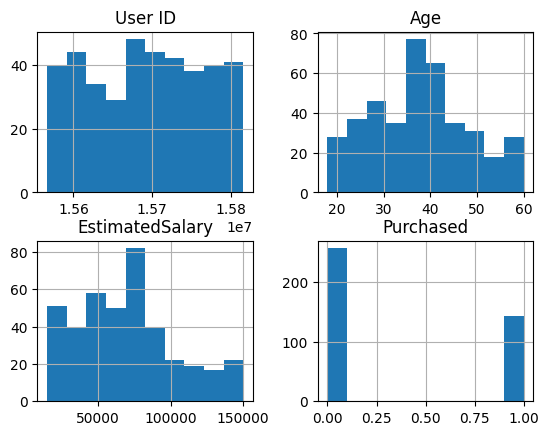

In [16]:
data.hist()

In [7]:
data.drop("Gender",inplace=True,axis=1)

In [14]:
X = data.drop("Purchased",axis=1).values

y = data['Purchased']

In [27]:
cv = KFold(n_splits=5,shuffle=True,random_state=42)
scores_test =[]
scores_train = []

for train_i,test_i in cv.split(X):
    x_train,x_test,y_train,y_test = X[train_i],X[test_i],y[train_i],y[test_i]
    sc = StandardScaler()
    x_train = sc.fit_transform(x_train)
    x_test = sc.transform(x_test)
    model = LogisticRegression(C=10, solver='newton-cg')
    model.fit(x_train,y_train)
    acc_test = accuracy_score(y_test,model.predict(x_test))
    acc_train = accuracy_score(y_train,model.predict(x_train))
    scores_test.append(acc_test)
    scores_train.append(acc_train)
print(scores_train)
print(scores_test)
np.mean(scores_train), np.mean(scores_test)

[0.8375, 0.8375, 0.853125, 0.865625, 0.859375]
[0.8875, 0.85, 0.85, 0.8375, 0.85]


(np.float64(0.8506250000000002), np.float64(0.8549999999999999))

In [ ]:
[0.840625, 0.840625, 0.853125, 0.865625, 0.85625]
[0.8625, 0.85, 0.85, 0.825, 0.85]
(np.float64(0.85125), np.float64(0.8474999999999999))